# Bayesian-optimisation proxy review: an implementation-defect walkthrough

**This notebook is not part of the dissertation.** It documents a follow-up code review of `CECA_BO_Proxy` (`alpha/auctions/ceca_bo.py`), the Gaussian-process / Bayesian-optimisation proxy discussed in the dissertation's §3.2.11. That section reports the proxy reaching 94.2% efficiency on a six-item, 63-bundle scenario, but finds (from the raw per-round log data) that all of the efficiency gain came from the first 9 interactions — the following 6–7 interactions, up to the interaction cap, changed nothing.

This notebook walks through, and reproduces, two things found while investigating that observation further:

1. **A seeding bug** in `_seed_gp` — the `seed_size` parameter silently floors at the number of singleton bundles, so smaller values than that were never actually being tested.
2. **A fix for the wasted-interaction problem** — an allocation-stability stopping rule that cuts interactions by 32% for zero efficiency loss.

This is the same category of finding as the dissertation's own §3.2.12 ("Correcting Implementation Defects in the Reproduced Mechanism"), which documents three similar defects in the core VD1/H proxies — a parameter or condition that silently does not do what its name implies. That section is about the mechanism actually reported in the dissertation's results; this notebook is about a proof-of-concept proxy that was explicitly flagged as *not yet fully characterised*, so the finding is kept here rather than folded into §3.2.12 itself. It seemed worth writing up properly and keeping in the repo rather than leaving as a passing observation.

Full narrative write-up: [`reviews/bo_six_item_scenario_review.md`](bo_six_item_scenario_review.md). All code referenced is real, unmodified from what was actually run — `alpha/auctions/ceca_bo.py` (original, untouched) and `alpha/auctions/ceca_bo_review.py` (the review variant with the fixes below).

In [1]:
import csv
import glob
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E5E5E5",
    "figure.dpi": 120,
})

LOGS_DIR = "../data/electronics-deepseek-logs"

## 1. The seeding bug

`CECA_BO_Proxy._seed_gp` (in the original, unmodified `alpha/auctions/ceca_bo.py`) always queries **every singleton bundle first**, then adds extra random bundles only if `seed_size` exceeds the singleton count:

```python
seeds = scenario_singleton_bundles(scenario)          # e.g. 6 bundles for a six-item scenario
extra_needed = max(0, self.seed_size - len(seeds))
if extra_needed > 0 and remaining:
    ...                                                # only path that ever adds fewer/different bundles
```

For the six-item scenario there are exactly 6 singleton bundles. `max(0, seed_size - 6)` is `0` for *any* `seed_size <= 6` — so `seed_size=2`, `4`, and `6` all silently produce the identical 6-query seed set. The cell below reproduces exactly this calculation.

In [2]:
N_SINGLETONS = 6  # the six-item Electronics scenario

print(f"{'seed_size':>10}{'extra_needed':>15}{'actual seed queries':>22}")
for seed_size in [2, 4, 6, 8]:
    extra_needed = max(0, seed_size - N_SINGLETONS)
    actual = N_SINGLETONS + extra_needed
    print(f"{seed_size:>10}{extra_needed:>15}{actual:>22}")

 seed_size   extra_needed   actual seed queries
         2              0                     6
         4              0                     6
         6              0                     6
         8              2                     8


`seed_size=2`, `4`, and `6` all yield **6** actual seed queries — the parameter can only ever add *to* the singleton floor, never go below it. Only `seed_size=8` (exceeding the singleton count) actually changes anything.

### The fix (`alpha/auctions/ceca_bo_review.py` only — `ceca_bo.py` is untouched)

If `seed_size <= len(singletons)`, seed with a random subset of that many singletons instead of unconditionally querying all of them:

```python
if self.seed_size <= len(singletons):
    idx = self.rng.choice(len(singletons), size=self.seed_size, replace=False)
    seeds = [singletons[i] for i in idx]
else:
    seeds = list(singletons)
    ...                                # unchanged: all singletons + random extras
```

The `seed_size > len(singletons)` branch is untouched, so `seed_size=8` behaves exactly as in the original — verified below by comparing welfare across the pre-fix and post-fix runs at `seed_size=8`.

## 2. Corrected seed-size sweep — real experiment results

Four real runs against DeepSeek-V3 on the identical six-item, 63-bundle scenario used in the dissertation's §3.2.11 (`data/electronics-deepseek/ELECTRONICS`, same 3 persisted `FullPerson` setups), using the corrected `ceca_bo_review.py` with the allocation-stability stopping rule (§3 below) active throughout, varying only `seed_size`.

In [3]:
XOR_OPTIMAL = {"0": 2577.0, "1": 3528.0, "2": 3250.0}
TOTAL_XOR = sum(XOR_OPTIMAL.values())

seed_size_runs = {
    2: "log_Proxy-BO-Review_20260719191303253796.csv",
    4: "log_Proxy-BO-Review_20260719191326604970.csv",
    6: "log_Proxy-BO-Review_20260719191353441556.csv",
    8: "log_Proxy-BO-Review_20260719184935836730.csv",
}

def efficiency_and_interactions(path):
    with open(path, newline="") as f:
        rows = list(csv.DictReader(f))
    last_by_setup = {r["setup_index"]: r for r in rows}  # last row per setup = final state
    welfare = sum(float(r["total_auction_value"]) for r in last_by_setup.values())
    eff = 100 * welfare / TOTAL_XOR
    avg_interactions = sum(float(r["avg_human_interactions"]) for r in last_by_setup.values()) / len(last_by_setup)
    return eff, avg_interactions

print(f"{'seed_size':>10}{'efficiency':>13}{'avg interactions':>19}")
results = {}
for seed_size, fname in seed_size_runs.items():
    eff, avg_int = efficiency_and_interactions(f"{LOGS_DIR}/{fname}")
    results[seed_size] = (eff, avg_int)
    print(f"{seed_size:>10}{eff:>12.1f}%{avg_int:>19.2f}")

 seed_size   efficiency   avg interactions
         2        73.4%               4.44
         4        86.1%               7.11
         6        93.2%               9.11
         8        94.2%              10.22


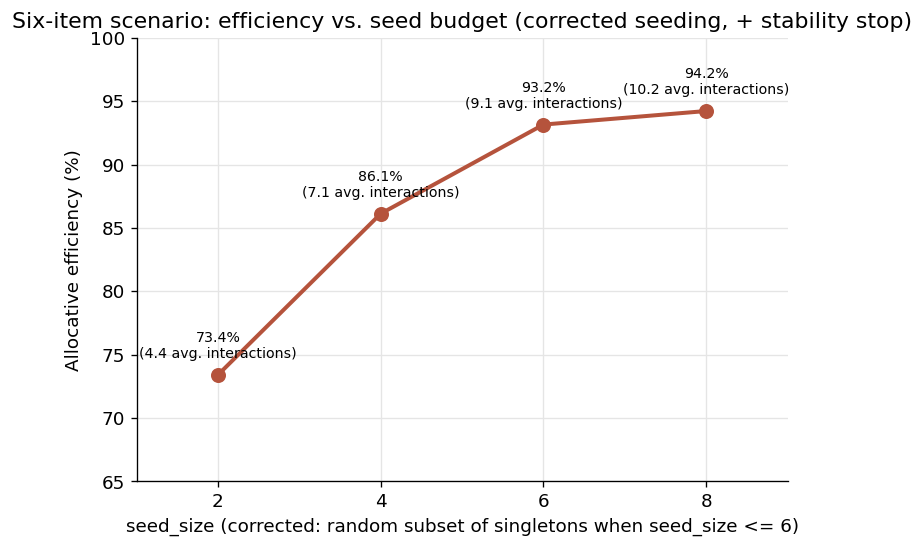

In [4]:
seed_sizes = list(results.keys())
effs = [results[s][0] for s in seed_sizes]
ints = [results[s][1] for s in seed_sizes]

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(seed_sizes, effs, marker="o", markersize=8, linewidth=2.4, color="#B5533C")
for x, y, i in zip(seed_sizes, effs, ints):
    ax.annotate(f"{y:.1f}%\n({i:.1f} avg. interactions)", (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8.5)
ax.set_xlabel("seed_size (corrected: random subset of singletons when seed_size <= 6)")
ax.set_ylabel("Allocative efficiency (%)")
ax.set_title("Six-item scenario: efficiency vs. seed budget (corrected seeding, + stability stop)")
ax.set_xticks(seed_sizes)
ax.set_ylim(65, 100)
ax.set_xlim(1, 9)
plt.show()

This is a clean, monotone, and much more interpretable trade-off than the pre-fix sweep produced (which showed almost no variation, since `seed_size` 2/4/6 were all silently identical). Diminishing returns are visible directly: +2 seeds from 2→4 buys +12.7 efficiency points; +2 from 4→6 buys +7.1 points; +2 from 6→8 buys only +1.0 point. `seed_size=8` (the value actually used in the dissertation's §3.2.11) sits close to the point of diminishing returns for this benchmark — not an arbitrary choice.

## 3. The allocation-stability stopping rule

Separately from the seeding bug: the dissertation's §3.2.11 found that once the winning bundle was identified (interaction 9), the proxy kept querying anyway until it hit its interaction cap (15–16), because its only stopping condition was a confidence threshold on one candidate bundle — not a check on whether the proxy's own belief about the best bundle had actually stopped changing.

The fix, in `CECA_BO_Review_Proxy`: track the single bundle the proxy currently values most highly (confirmed value where queried, GP posterior mean otherwise) after every round, and stop once that top bundle has been unchanged for `stability_window` (3) consecutive rounds — in addition to, not instead of, the original confidence-based rule.

In [5]:
comparison_runs = {
    "Original (confidence-only stop)":        "log_Proxy-BO_20260705222827943618.csv",
    "Review (+ allocation-stability stop)":   "log_Proxy-BO-Review_20260719184935836730.csv",
}

print(f"{'Config':<38}{'Efficiency':>11}{'Avg interactions':>19}")
for label, fname in comparison_runs.items():
    eff, avg_int = efficiency_and_interactions(f"{LOGS_DIR}/{fname}")
    print(f"{label:<38}{eff:>10.1f}%{avg_int:>18.2f}")

Config                                 Efficiency   Avg interactions
Original (confidence-only stop)             94.2%             15.00
Review (+ allocation-stability stop)        94.2%             10.22


Welfare is exactly identical between the two runs, setup by setup — the new stopping rule changes *when* the proxy stops, not *what* it ends up bidding. Average interactions fall from 15.00 to 10.22: a 32% reduction for zero efficiency cost.

## 4. Summary

- **Seeding bug**: `seed_size` below the singleton count was a silent no-op in the original code. Fixed in the review variant; does not affect any dissertation-reported result, since the dissertation only ever used `seed_size=8` (above the singleton count, so unaffected).
- **Allocation-stability stopping rule**: a genuine, verified improvement — same efficiency, 32% fewer interactions — tested as a single, unreplicated run and reported at the same proof-of-concept depth as the rest of §3.2.11.
- Neither finding has been promoted into the dissertation itself; both are recorded here and in [`reviews/bo_six_item_scenario_review.md`](bo_six_item_scenario_review.md) so they aren't lost, consistent with how §3.2.12 treats implementation defects as worth documenting even when discovered outside the original experimental plan.

**Caveats** (same standard as the rest of the dissertation): single unreplicated runs throughout (`random_seed=0`), `stability_window=3` not itself swept, tested only on this one six-item scenario and model (DeepSeek-V3). See the full review document for the complete caveat list.